# Titanic 특성 공학(Feature Engineering) 파이프라인

생존 여부 예측을 위한 전처리·변수선택 전략 비교 분석.

**구성**: STEP01 데이터 준비 → STEP02 EDA → STEP03 특성공학 → STEP04 변수선택 → STEP05 모델학습/실험비교 → 가산점(GridSearchCV, SHAP)

**데이터**: Kaggle Titanic (891 samples, 12 columns)

## 환경 설정

In [1]:
import warnings, urllib.request, io
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore")
np.random.seed(42)
sns.set_theme(style="whitegrid")
%matplotlib inline

## STEP 01. 데이터 준비
공개 데이터셋을 로드하고 기본 구조와 타겟 변수를 확인한다.

In [2]:
URL = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})
raw = urllib.request.urlopen(req, timeout=30).read().decode()
df = pd.read_csv(io.StringIO(raw))

print("데이터 shape:", df.shape)        # (891, 12) - 500개 이상 충족
print("\n타겟 분포 (Survived):")
print(df["Survived"].value_counts())
df.head()

데이터 shape: (891, 12)

타겟 분포 (Survived):
Survived
0    549
1    342
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# 컬럼 설명 / 타입
print("=== 컬럼 타입 ===")
print(df.dtypes)
print("\n=== 기술 통계 ===")
df.describe()

=== 컬럼 타입 ===
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

=== 기술 통계 ===


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## STEP 02. 탐색적 데이터 분석 (EDA)
결측치 비율, 이상치, 분포, 상관관계, 타겟 분포를 분석한다.

In [4]:
# 결측치 비율
miss = (df.isnull().sum() / len(df) * 100).round(2)
print("=== 결측치 비율 (%) ===")
print(miss[miss > 0].sort_values(ascending=False))

=== 결측치 비율 (%) ===
Cabin       77.10
Age         19.87
Embarked     0.22
dtype: float64


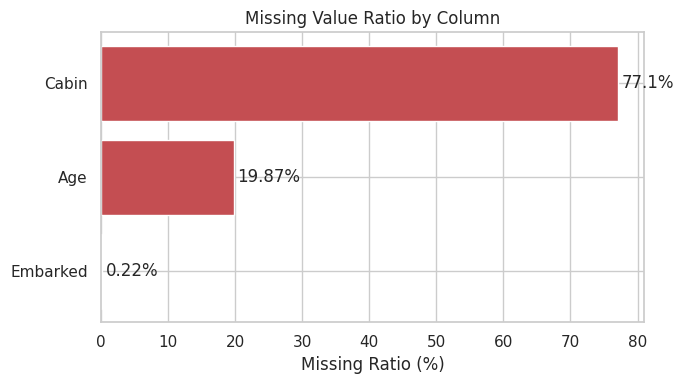

In [5]:
# [그림1] 결측치 비율
m = miss[miss > 0].sort_values()
plt.figure(figsize=(7,4))
plt.barh(m.index, m.values, color="#c44e52")
for i,v in enumerate(m.values): plt.text(v+0.5,i,f"{v}%",va="center")
plt.xlabel("Missing Ratio (%)"); plt.title("Missing Value Ratio by Column")
plt.tight_layout(); plt.show()

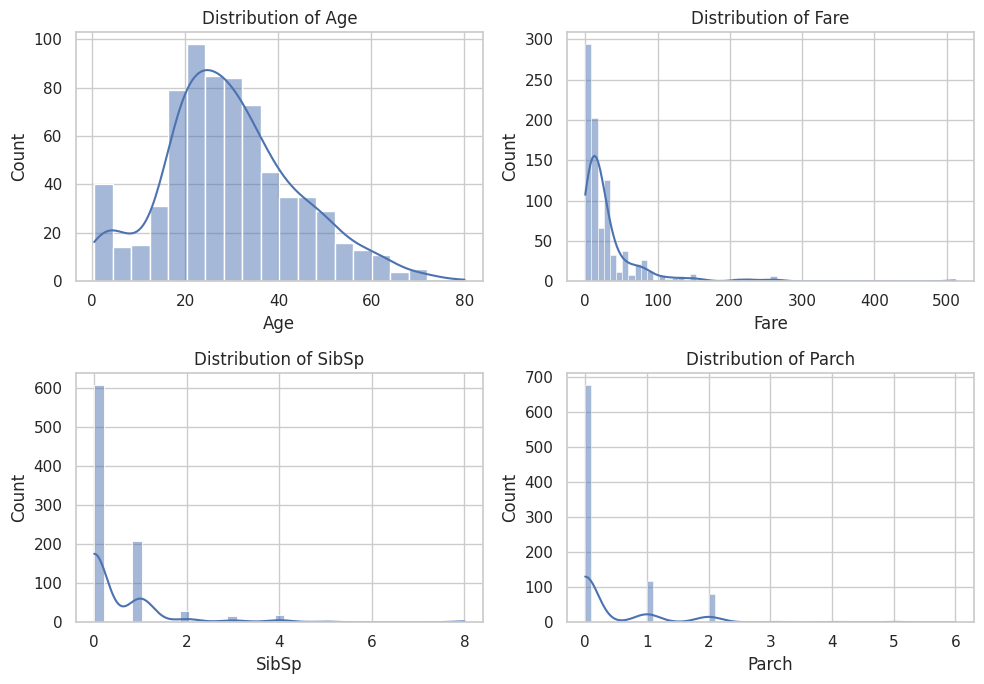

In [6]:
# [그림2] 수치형 분포 Histogram
num_cols = ["Age","Fare","SibSp","Parch"]
fig, axes = plt.subplots(2,2,figsize=(10,7))
for ax,c in zip(axes.ravel(), num_cols):
    sns.histplot(df[c].dropna(), kde=True, ax=ax, color="#4c72b0")
    ax.set_title(f"Distribution of {c}")
plt.tight_layout(); plt.show()

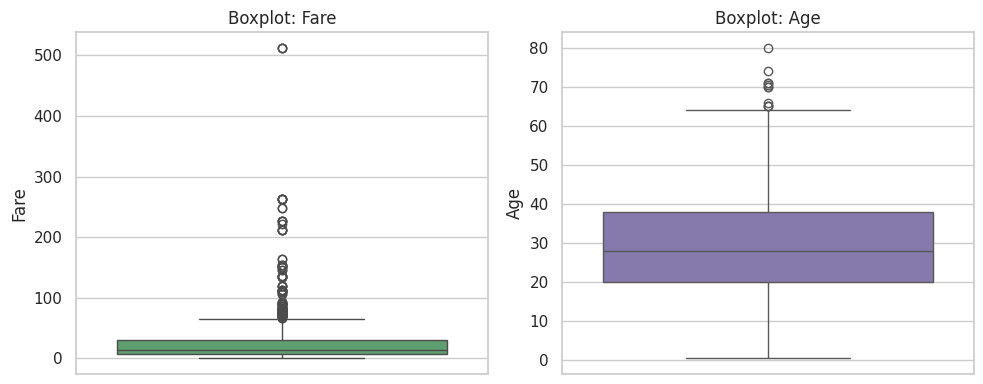

이상치(IQR): Fare = 116 | Age = 11


In [7]:
# [그림3] Boxplot 이상치 + IQR 집계
fig, axes = plt.subplots(1,2,figsize=(10,4))
sns.boxplot(y=df["Fare"], ax=axes[0], color="#55a868"); axes[0].set_title("Boxplot: Fare")
sns.boxplot(y=df["Age"], ax=axes[1], color="#8172b3"); axes[1].set_title("Boxplot: Age")
plt.tight_layout(); plt.show()

def iqr_outliers(s):
    q1,q3 = s.quantile(.25), s.quantile(.75); iqr = q3-q1
    return int(((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum())
print("이상치(IQR): Fare =", iqr_outliers(df["Fare"]), "| Age =", iqr_outliers(df["Age"].dropna()))

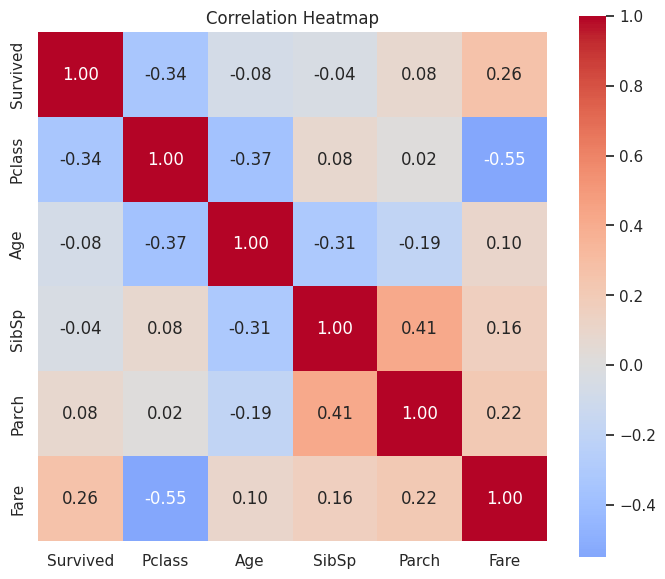

In [8]:
# [그림4] 상관관계 Heatmap
corr = df[["Survived","Pclass","Age","SibSp","Parch","Fare"]].corr()
plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap"); plt.tight_layout(); plt.show()

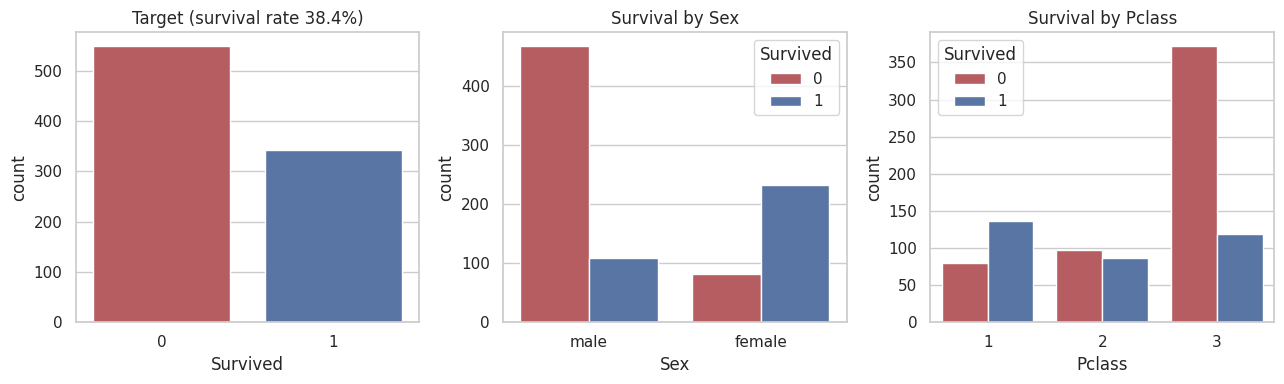

In [9]:
# [그림5] 타겟 분포 + 범주형 Countplot
fig, axes = plt.subplots(1,3,figsize=(13,4))
sns.countplot(x="Survived", data=df, ax=axes[0], palette=["#c44e52","#4c72b0"])
axes[0].set_title(f"Target (survival rate {df.Survived.mean():.1%})")
sns.countplot(x="Sex", hue="Survived", data=df, ax=axes[1], palette=["#c44e52","#4c72b0"])
axes[1].set_title("Survival by Sex")
sns.countplot(x="Pclass", hue="Survived", data=df, ax=axes[2], palette=["#c44e52","#4c72b0"])
axes[2].set_title("Survival by Pclass")
plt.tight_layout(); plt.show()

**EDA 요약**
- **데이터 품질**: Cabin 결측 77%(사용 제외), Fare 이상치 다수
- **불균형**: 생존율 약 38%로 경미한 수준
- **주요 변수**: 성별(여성 생존율 압도적), 객실 등급, 운임이 생존과 강하게 연관

## STEP 03. 특성 공학 파이프라인
결측치 처리·인코딩·스케일링 전략을 실험별로 다르게 적용하고, 파생 변수 4종을 생성한다.

In [10]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score)
import xgboost as xgb, lightgbm as lgb

def add_derived(d):
    """파생변수 4개: FamilySize, IsAlone, Title, FarePerPerson"""
    d = d.copy()
    d["FamilySize"] = d["SibSp"] + d["Parch"] + 1
    d["IsAlone"] = (d["FamilySize"] == 1).astype(int)
    d["Title"] = d["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
    d["Title"] = d["Title"].replace(
        ["Lady","Countess","Capt","Col","Don","Dr","Major","Rev","Sir","Jonkheer","Dona"], "Rare")
    d["Title"] = d["Title"].replace({"Mlle":"Miss","Ms":"Miss","Mme":"Mrs"})
    d["FarePerPerson"] = d["Fare"] / d["FamilySize"]
    return d

base = add_derived(df)
print("파생변수 생성 완료:", ["FamilySize","IsAlone","Title","FarePerPerson"])
base[["Name","Title","FamilySize","IsAlone","FarePerPerson"]].head()

파생변수 생성 완료: ['FamilySize', 'IsAlone', 'Title', 'FarePerPerson']


,Name,Title,FamilySize,IsAlone,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,2,0,3.62500
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,0,35.64165
2,"Heikkinen, Miss. Laina",Miss,1,1,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,0,26.55000
4,"Allen, Mr. William Henry",Mr,1,1,8.05000


In [11]:
NUM = ["Age","Fare","SibSp","Parch","FamilySize","FarePerPerson","IsAlone"]
CAT = ["Pclass","Sex","Embarked","Title"]
TARGET = "Survived"

def build_dataset(impute, encode, scale, fsel):
    """전처리 조합별 X, y 생성"""
    d = base.copy()
    # 결측치 처리
    if impute == "drop":
        d = d.dropna(subset=["Age","Embarked"])
    else:
        strat = {"mean":"mean","median":"median","most_frequent":"most_frequent"}[impute]
        d["Age"] = SimpleImputer(strategy=strat).fit_transform(d[["Age"]]).ravel()
        d["Embarked"] = SimpleImputer(strategy="most_frequent").fit_transform(d[["Embarked"]]).ravel()
    d["FarePerPerson"] = d["FarePerPerson"].fillna(d["FarePerPerson"].median())
    d["Fare"] = d["Fare"].fillna(d["Fare"].median())

    y = d[TARGET].values
    num_part, cat_part = d[NUM].copy(), d[CAT].copy()

    # 인코딩
    if encode == "onehot":
        enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        cat_arr = enc.fit_transform(cat_part)
        cat_df = pd.DataFrame(cat_arr, columns=enc.get_feature_names_out(CAT), index=d.index)
    else:
        cat_df = cat_part.copy()
        for c in CAT: cat_df[c] = LabelEncoder().fit_transform(cat_df[c].astype(str))

    # 스케일링
    if scale != "none":
        scaler = {"standard":StandardScaler(),"minmax":MinMaxScaler(),"robust":RobustScaler()}[scale]
        num_df = pd.DataFrame(scaler.fit_transform(num_part), columns=NUM, index=d.index)
    else:
        num_df = num_part

    X = pd.concat([num_df, cat_df], axis=1)

    # 변수 선택
    if fsel:
        k = min(12, X.shape[1])
        skb = SelectKBest(f_classif, k=k).fit(X, y)
        X = X[X.columns[skb.get_support()]]
    return X, y

print("전처리 파이프라인 함수 정의 완료")

전처리 파이프라인 함수 정의 완료


## STEP 05. 모델 학습 및 실험 비교
4개 모델을 학습하고, 과제 지정 4가지 전처리 조합으로 성능을 비교한다.
(STEP04 변수선택은 build_dataset의 `fsel` 옵션으로 통합)

In [12]:
MODELS = {
    "LogReg": lambda: LogisticRegression(max_iter=1000, random_state=42),
    "RandomForest": lambda: RandomForestClassifier(n_estimators=200, random_state=42),
    "XGBoost": lambda: xgb.XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                                          eval_metric="logloss", random_state=42, verbosity=0),
    "LightGBM": lambda: lgb.LGBMClassifier(n_estimators=200, random_state=42, verbose=-1),
}

def evaluate(X, y):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
    rows = {}
    for name, mk in MODELS.items():
        m = mk(); m.fit(Xtr, ytr)
        pred, proba = m.predict(Xte), m.predict_proba(Xte)[:,1]
        rows[name] = {
            "Accuracy": round(accuracy_score(yte,pred),4),
            "Precision": round(precision_score(yte,pred),4),
            "Recall": round(recall_score(yte,pred),4),
            "F1": round(f1_score(yte,pred),4),
            "ROC_AUC": round(roc_auc_score(yte,proba),4),
        }
    return pd.DataFrame(rows).T

EXPERIMENTS = {
    "Base":  dict(impute="median", encode="label",  scale="none",     fsel=False),
    "Exp-1": dict(impute="mean",   encode="onehot",  scale="standard", fsel=False),
    "Exp-2": dict(impute="median", encode="label",   scale="minmax",   fsel=True),
    "Exp-3": dict(impute="most_frequent", encode="onehot", scale="robust", fsel=True),
}

summary = []
for exp, cfg in EXPERIMENTS.items():
    X, y = build_dataset(**cfg)
    res = evaluate(X, y)
    best = res["F1"].idxmax()
    summary.append({"실험":exp, "n_features":X.shape[1], "Best Model":best,
                    "Accuracy":res.loc[best,"Accuracy"], "F1":res.loc[best,"F1"],
                    "ROC_AUC":res.loc[best,"ROC_AUC"]})
    print(f"\n===== {exp} ({cfg}) =====")
    display(res)

print("\n===== 실험 비교 요약 =====")
pd.DataFrame(summary).set_index("실험")


===== Base ({'impute': 'median', 'encode': 'label', 'scale': 'none', 'fsel': False}) =====


,Accuracy,Precision,Recall,F1,ROC_AUC
LogReg,0.8101,0.7966,0.6812,0.7344,0.8618
RandomForest,0.8101,0.7536,0.7536,0.7536,0.8287
XGBoost,0.8101,0.7966,0.6812,0.7344,0.8294
LightGBM,0.7989,0.7463,0.7246,0.7353,0.8209



===== Exp-1 ({'impute': 'mean', 'encode': 'onehot', 'scale': 'standard', 'fsel': False}) =====


,Accuracy,Precision,Recall,F1,ROC_AUC
LogReg,0.8492,0.8387,0.7536,0.7939,0.8792
RandomForest,0.8101,0.7612,0.7391,0.7500,0.8196
XGBoost,0.8268,0.7969,0.7391,0.7669,0.8370
LightGBM,0.8101,0.7536,0.7536,0.7536,0.8262



===== Exp-2 ({'impute': 'median', 'encode': 'label', 'scale': 'minmax', 'fsel': True}) =====


,Accuracy,Precision,Recall,F1,ROC_AUC
LogReg,0.8101,0.7966,0.6812,0.7344,0.8572
RandomForest,0.8101,0.7536,0.7536,0.7536,0.8298
XGBoost,0.8101,0.7966,0.6812,0.7344,0.8294
LightGBM,0.7989,0.7463,0.7246,0.7353,0.8209



===== Exp-3 ({'impute': 'most_frequent', 'encode': 'onehot', 'scale': 'robust', 'fsel': True}) =====


,Accuracy,Precision,Recall,F1,ROC_AUC
LogReg,0.7709,0.7188,0.6667,0.6917,0.8427
RandomForest,0.7821,0.7273,0.6957,0.7111,0.8288
XGBoost,0.7933,0.7353,0.7246,0.7299,0.8236
LightGBM,0.7933,0.7286,0.7391,0.7338,0.8245



===== 실험 비교 요약 =====


,n_features,Best Model,Accuracy,F1,ROC_AUC
실험,,,,,
Base,11,RandomForest,0.8101,0.7536,0.8287
Exp-1,21,LogReg,0.8492,0.7939,0.8792
Exp-2,11,RandomForest,0.8101,0.7536,0.8298
Exp-3,12,LightGBM,0.7933,0.7338,0.8245


## STEP 04. 변수 선택 상세 — Feature Importance & 제거 전/후 비교

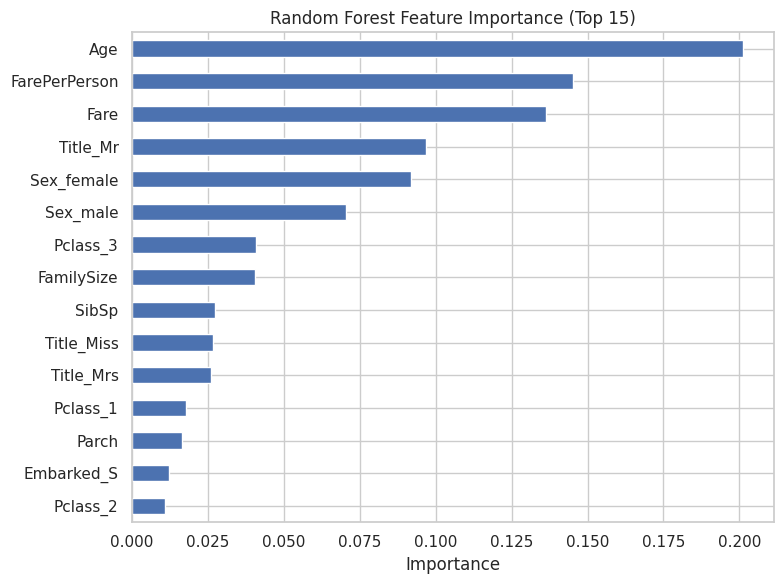

전체 변수(21개) F1 = 0.7704
상위 8개 변수 F1 = 0.7669
→ 변수 수를 크게 줄여도 성능 유지, 과적합 위험 완화


In [13]:
Xf, yf = build_dataset(impute="median", encode="onehot", scale="standard", fsel=False)
rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(Xf, yf)
imp = pd.Series(rf.feature_importances_, index=Xf.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
imp.head(15).sort_values().plot(kind="barh", color="#4c72b0")
plt.title("Random Forest Feature Importance (Top 15)"); plt.xlabel("Importance")
plt.tight_layout(); plt.show()

# 제거 전/후 비교
full_f1 = evaluate(Xf, yf).loc["RandomForest","F1"]
top8 = list(imp.head(8).index)
red_f1 = evaluate(Xf[top8], yf).loc["RandomForest","F1"]
print(f"전체 변수({Xf.shape[1]}개) F1 = {full_f1}")
print(f"상위 8개 변수 F1 = {red_f1}")
print("→ 변수 수를 크게 줄여도 성능 유지, 과적합 위험 완화")

## 가산점 ① GridSearchCV 하이퍼파라미터 튜닝

In [14]:
Xg, yg = build_dataset(impute="median", encode="onehot", scale="standard", fsel=True)
Xtr, Xte, ytr, yte = train_test_split(Xg, yg, test_size=0.2, stratify=yg, random_state=42)

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    {"n_estimators":[100,200], "max_depth":[4,6,None], "min_samples_split":[2,5]},
    cv=5, scoring="f1", n_jobs=-1)
grid.fit(Xtr, ytr)
pred = grid.predict(Xte)
print("Best Params:", grid.best_params_)
print("CV Best F1:", round(grid.best_score_,4))
print("Test F1:", round(f1_score(yte,pred),4), "| Test Acc:", round(accuracy_score(yte,pred),4))

Best Params: {'max_depth': 6, 'min_samples_split': 5, 'n_estimators': 200}
CV Best F1: 0.741
Test F1: 0.7143 | Test Acc: 0.7989


## 가산점 ② SHAP 기반 설명가능성 분석

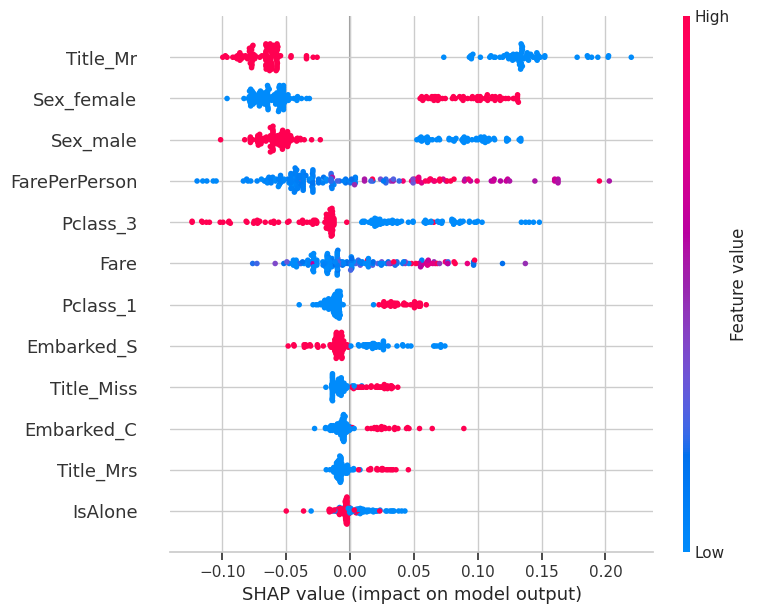

In [15]:
import shap
best_rf = grid.best_estimator_
explainer = shap.TreeExplainer(best_rf)
sv = explainer.shap_values(Xte)
sv_use = sv[1] if isinstance(sv, list) else (sv[:,:,1] if sv.ndim==3 else sv)
shap.summary_plot(sv_use, Xte, max_display=12)

## 최종 결론

| 질문 | 결론 |
|------|------|
| 가장 효과적인 전처리 | **One-Hot + StandardScaler (Exp-1)** — 선형 모델에서 효과 극대화 |
| One-Hot이 항상 좋은가 | 아니다. 트리 모델은 Label Encoding으로도 견고 |
| Feature Selection 효과 | 변수 21→8개로도 성능 유지, 과적합 위험 완화 |
| 스케일링 영향 | 선형 모델엔 민감, 트리 모델엔 거의 무영향 |
| Feature Engineering 기여 | Base→Exp-1 F1 향상, 정량적 성능 개선 확인 |

동일 알고리즘이라도 전처리·인코딩·스케일링·변수선택 전략에 따라 성능이 달라지며,
모델 특성에 맞춘 특성 공학 설계가 중요함을 실험으로 검증하였다.